In [1]:
!pip install pandas


[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: C:\Users\yaass\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: C:\Users\yaass\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../datasets/ml_training_dataset_v3_cleaned.csv")

In [5]:
df.head()


,application_type,expected_users_per_day,concurrent_users,storage_required_gb,deployment_region,required_vcpu,required_ram_gb,cloud_provider_reference,reference_vm_type,price_per_hour,traffic_pattern,monthly_cost
0,Blog,909,90,20,us-east,1,2,Azure,B2s,0.0501,Low,36.07
1,E-Commerce,18434,4667,94,us-west,2,4,Azure,B2s,0.0499,Medium,35.93
2,Healthcare,9165,322,147,asia-south,2,4,GCP,e2-medium,0.0340,Medium,24.48
3,ERP,142475,2965,113,us-east,8,16,AWS,c5.2xlarge,0.3497,High,251.78
4,ERP,119974,1402,329,us-east,8,16,AWS,c5.2xlarge,0.3379,High,243.29


In [6]:
df.shape

(15000, 12)

In [7]:
df.columns

Index(['application_type', 'expected_users_per_day', 'concurrent_users',
       'storage_required_gb', 'deployment_region', 'required_vcpu',
       'required_ram_gb', 'cloud_provider_reference', 'reference_vm_type',
       'price_per_hour', 'traffic_pattern', 'monthly_cost'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   application_type          15000 non-null  str    
 1   expected_users_per_day    15000 non-null  int64  
 2   concurrent_users          15000 non-null  int64  
 3   storage_required_gb       15000 non-null  int64  
 4   deployment_region         15000 non-null  str    
 5   required_vcpu             15000 non-null  int64  
 6   required_ram_gb           15000 non-null  int64  
 7   cloud_provider_reference  15000 non-null  str    
 8   reference_vm_type         15000 non-null  str    
 9   price_per_hour            15000 non-null  float64
 10  traffic_pattern           15000 non-null  str    
 11  monthly_cost              15000 non-null  float64
dtypes: float64(2), int64(5), str(5)
memory usage: 1.4 MB


In [9]:
df.isnull().sum()

application_type            0
expected_users_per_day      0
concurrent_users            0
storage_required_gb         0
deployment_region           0
required_vcpu               0
required_ram_gb             0
cloud_provider_reference    0
reference_vm_type           0
price_per_hour              0
traffic_pattern             0
monthly_cost                0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,expected_users_per_day,concurrent_users,storage_required_gb,required_vcpu,required_ram_gb,price_per_hour,monthly_cost
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,94608.449600,3395.902133,623.241000,5.239667,10.479333,0.172111,123.920085
std,112796.950441,4560.143637,983.412354,4.342183,8.684365,0.116827,84.115214
min,100.000000,5.000000,1.000000,1.000000,2.000000,0.016500,11.880000
25%,15587.750000,551.000000,89.000000,2.000000,4.000000,0.049200,35.420000
50%,59956.000000,1827.500000,234.000000,4.000000,8.000000,0.189200,136.220000
75%,116828.750000,3779.250000,511.250000,8.000000,16.000000,0.196825,141.717500
max,499846.000000,19993.000000,4989.000000,16.000000,32.000000,0.399600,287.710000


In [15]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: C:\Users\yaass\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("ggplot")

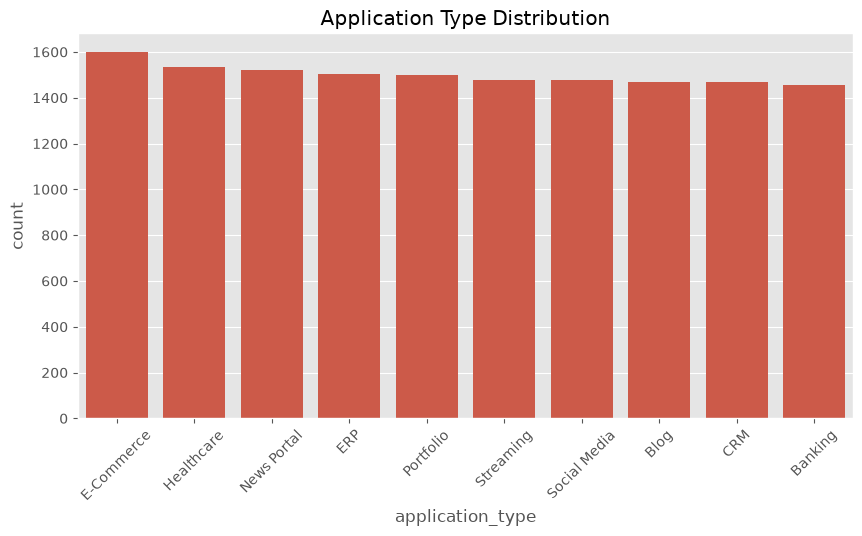

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="application_type",
    order=df["application_type"].value_counts().index
)

plt.title("Application Type Distribution")
plt.xticks(rotation=45)
plt.show()

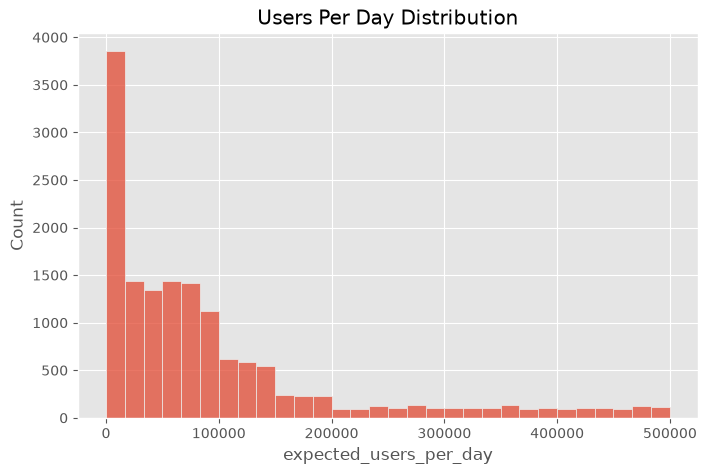

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["expected_users_per_day"], bins=30)

plt.title("Users Per Day Distribution")
plt.show()

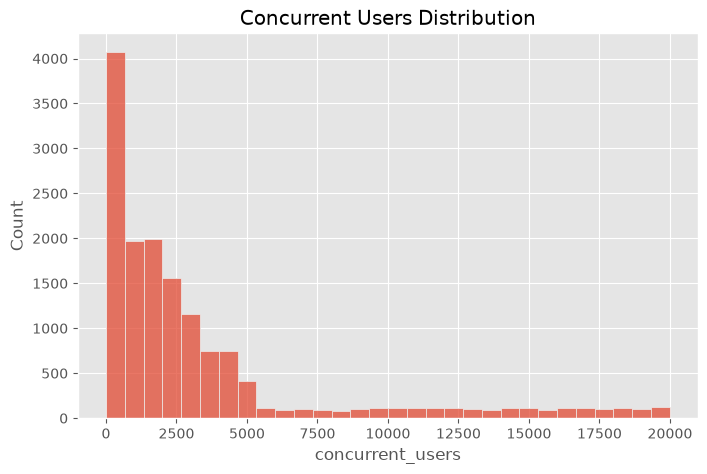

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["concurrent_users"], bins=30)

plt.title("Concurrent Users Distribution")
plt.show()

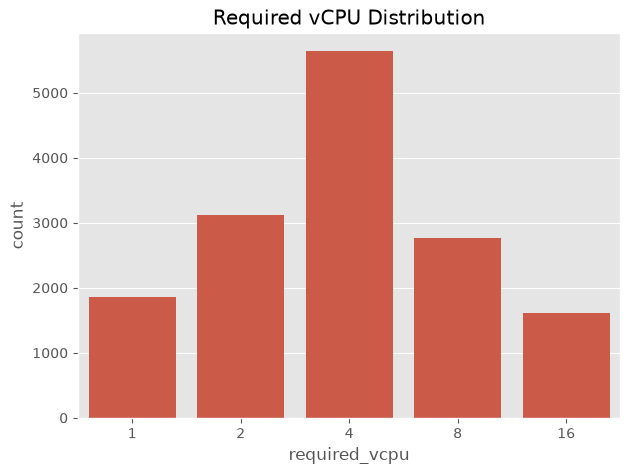

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="required_vcpu")

plt.title("Required vCPU Distribution")
plt.show()

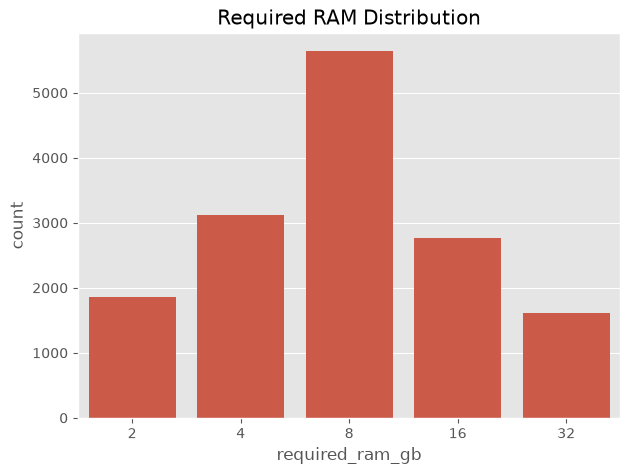

In [21]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="required_ram_gb")

plt.title("Required RAM Distribution")
plt.show()

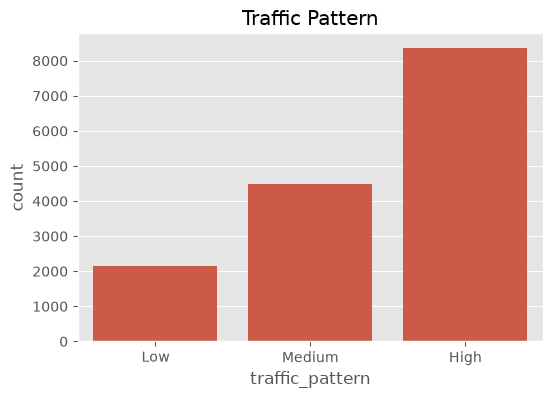

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="traffic_pattern")

plt.title("Traffic Pattern")
plt.show()

In [23]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

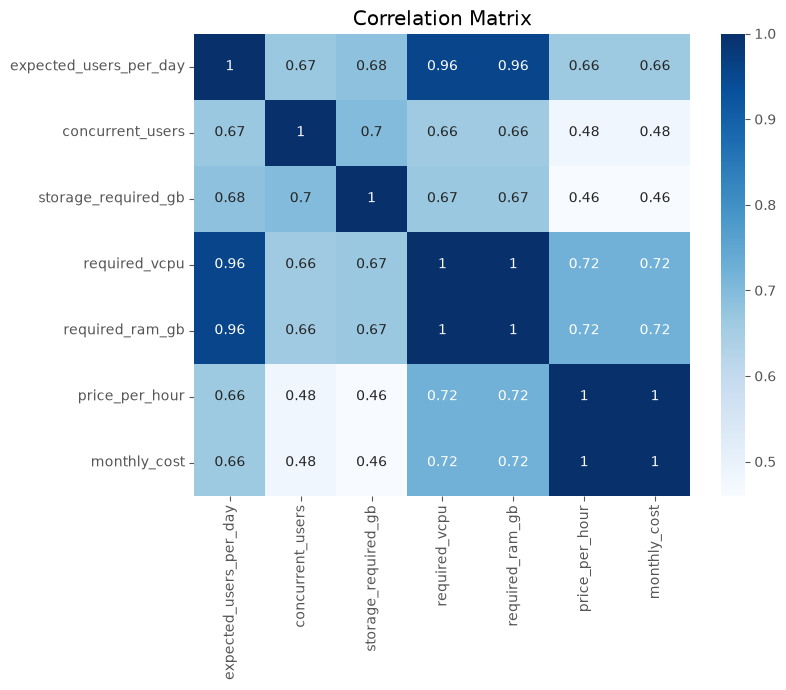

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")

plt.title("Correlation Matrix")
plt.show()